In [148]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [149]:
eda = pd.read_csv("data/doctors_eda_result.csv")
eda.head()

,Unnamed: 0,name,experience,rating_sber,review_count_sber,price_sber,link_sber,clinics_count_sber,clinic_1_name_sber,clinic_1_address_sber,...,comment_prod,doctor_source,experience_category,rating_sber_norm,rating,price,price_category_sber,price_category_prod,price_category_avg,price_tier
0,0,Абросимова Елена Владимировна,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ProDoctorov,21-30 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Абросимова Елена Владимировна,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ProDoctorov,Более 30 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Агеева Наталья Юрьевна,18.0,4.5,0.0,3500.0,https://docdoc.ru/doctor/Ageeva_Natalya_12,1.0,Будь Здоров на Рязанском проспекте,"г. Москва, ул. Рязанский пр-т, д. 2Б",...,NaN,SberHealth,16-20 лет,4.125,4.125,3500.0,3k-5k,NaN,NaN,Средний
3,3,Агеева Наталья Юрьевна,NaN,4.0,0.0,NaN,https://docdoc.ru/doctor/Ageeva_Natalya_3,0.0,NaN,NaN,...,NaN,SberHealth,No value,3.250,3.250,NaN,NaN,NaN,NaN,NaN
4,4,Акимова Анна Владимировна,18.0,4.3,0.0,NaN,https://docdoc.ru/doctor/Akimova_Anna_7,0.0,NaN,NaN,...,NaN,SberHealth,16-20 лет,3.775,3.775,NaN,NaN,NaN,NaN,NaN


In [150]:
eda.shape

(38865, 47)

In [151]:
# сколько врачей с ценой
print("всего врачей:", len(eda))
print("с ценой (price):", eda["price"].notna().sum())

eda[["name", "price_sber", "price_prod", "price"]].head(10)

всего врачей: 38865
с ценой (price): 7210


,name,price_sber,price_prod,price
0,Абросимова Елена Владимировна,NaN,NaN,NaN
1,Абросимова Елена Владимировна,NaN,NaN,NaN
2,Агеева Наталья Юрьевна,3500.0,NaN,3500.0
3,Агеева Наталья Юрьевна,NaN,NaN,NaN
4,Акимова Анна Владимировна,NaN,NaN,NaN
5,Акимова Анна Владимировна,NaN,NaN,NaN
6,Алексеева Екатерина Михайловна,5000.0,NaN,5000.0
7,Алексеева Екатерина Михайловна,NaN,NaN,NaN
8,Алексеева Марина Михайловна,NaN,7000.0,7000.0
9,Алексеева Марина Михайловна,NaN,5000.0,5000.0


In [152]:
#число отзывов = сумма по двум площадкам (пустые считаем за 0)
eda["review_count"] = eda["review_count_sber"].fillna(0) + eda["review_count_prod"].fillna(0)

#тоже самое но для клиник
eda["clinics_count"] = eda["clinics_count_sber"].fillna(0) + eda["clinics_count_prod"].fillna(0)

eda[["name", "review_count", "clinics_count"]]

,name,review_count,clinics_count
0,Абросимова Елена Владимировна,0.0,1.0
1,Абросимова Елена Владимировна,0.0,1.0
2,Агеева Наталья Юрьевна,0.0,1.0
3,Агеева Наталья Юрьевна,0.0,0.0
4,Акимова Анна Владимировна,0.0,0.0
...,...,...,...
38860,Ященко Елена Николаевна,8.0,1.0
38861,Ященко Ирина Анатольевна,2.0,1.0
38862,Ящина Ольга Владимировна,6.0,1.0
38863,Ящук Сергей Борисович,14.0,1.0


Далее, так как у нас у одного врача много специальностей, то модель будет воспринимать их как совершенно разные, например может быть такое: "кардиолог", "кардиолог, терапевт", "терапевт, кардиолог". Поэтому если мы оставим однц, то катеогрий резко меньше, в каждой нормальное число врачей, модель видит понятный признак

In [153]:
def main_speciality(raw):
    if pd.isna(raw):
        return np.nan
    first = raw.split(",")[0] #разделяем и берем первую
    return first.strip().lower()#чекаем чтоб пробелов не было

eda["spec"] = eda["speciality"].apply(main_speciality)

print("было уникальных:", eda["speciality"].nunique())
print("стало уникальных:", eda["spec"].nunique())
eda["spec"].value_counts().head()

было уникальных: 1727
стало уникальных: 125


spec
терапевт     7197
акушер       3662
невролог     2683
гинеколог    2207
онколог      1954
Name: count, dtype: int64

Дальше начинаем feuture engineering, начнем с подсчета расстояни до центра. Берем данные из api датасета

In [154]:
api = pd.read_csv("data/api_addresses.csv")
api

,level_0,address,address_norm,latitude,longitude,district,area,index
0,63210,"г. Москва, ул. Рязанский пр-т, д. 2Б","г. москва, улица рязанский пр-т, д. 2б",55.730487,37.738656,Нижегородский район,Юго-Восточный административный округ,43404.0
1,63211,"г. Москва, ул. Щукинская, д. 2","г. москва, улица щукинская, д. 2",55.809641,37.481936,район Щукино,Северо-Западный административный округ,43405.0
2,63212,"г. Москва, Последний пер., д. 28","г. москва, последний переулок, д. 28",55.769681,37.630625,Мещанский район,Центральный административный округ,43406.0
3,63213,"г. Москва, ул. Нагорная, д. 17, корп. 6","г. москва, улица нагорная, д. 17, корпус 6",55.677524,37.607709,район Котловка,Юго-Западный административный округ,43407.0
4,63214,"г. Тверь, ул. Крылова, д. 21","г. тверь, улица крылова, д. 21",NaN,NaN,NaN,NaN,43408.0
...,...,...,...,...,...,...,...,...
4744,67954,"Электролитный проезд, д. 16, корп. 2","электролитный проезд, д. 16, корпус 2",55.671280,37.611024,Нагорный район,Южный административный округ,64195.0
4745,67955,"Верея, пл. Советская, д. 1","верея, площадь советская, д. 1",NaN,NaN,NaN,NaN,64196.0
4746,67956,"ул. Люсиновская, д. 36, стр. 2","улица люсиновская, д. 36, стр 2",55.722852,37.620501,район Замоскворечье,Центральный административный округ,64197.0
4747,67957,"Котельники, ул. Кузьминская, д. 7Б","котельники, улица кузьминская, д. 7б",55.665274,37.867529,NaN,NaN,64198.0


In [155]:
# все колонки с адресами клиник
addr_cols = [
    "clinic_1_address_sber", "clinic_2_address_sber", "clinic_3_address_sber",
    "clinic_1_address_prod", "clinic_2_address_prod", "clinic_3_address_prod",
]

# берем первый непустой адрес по строке
eda["primary_address"] = eda[addr_cols].bfill(axis=1).iloc[:, 0]

print("врачей с адресом:", eda["primary_address"].notna().sum())
eda[["name", "primary_address"]].head()

врачей с адресом: 26495


,name,primary_address
0,Абросимова Елена Владимировна,"ул. Скульптора Мухиной, д. 14"
1,Абросимова Елена Владимировна,"пос. Внуковское, ул. Омская, д. 18"
2,Агеева Наталья Юрьевна,"г. Москва, ул. Рязанский пр-т, д. 2Б"
3,Агеева Наталья Юрьевна,NaN
4,Акимова Анна Владимировна,NaN


In [156]:
#из справочника берем только нужное: адрес, координаты, район
api_small = api[["address", "latitude", "longitude", "district"]].drop_duplicates("address")

# склеиваем по адресу
eda = eda.merge(api_small, left_on="primary_address", right_on="address", how="left")

print("координаты нашлись у:", eda["latitude"].notna().sum(), "из", len(eda))
eda[["name", "primary_address", "latitude", "longitude", "district"]].head()

координаты нашлись у: 24701 из 38865


,name,primary_address,latitude,longitude,district
0,Абросимова Елена Владимировна,"ул. Скульптора Мухиной, д. 14",55.638826,37.340029,район Ново-Переделкино
1,Абросимова Елена Владимировна,"пос. Внуковское, ул. Омская, д. 18",55.620169,37.263052,NaN
2,Агеева Наталья Юрьевна,"г. Москва, ул. Рязанский пр-т, д. 2Б",55.730487,37.738656,Нижегородский район
3,Агеева Наталья Юрьевна,NaN,NaN,NaN,NaN
4,Акимова Анна Владимировна,NaN,NaN,NaN,NaN


Теперь посчитаем расстояния на центра 

In [157]:
MOSCOW_LAT = 55.7539 #координаты кремля
MOSCOW_LON = 37.6208

def distance_to_center(lat, lon):
    #формула гаверсинуса: расстояние по поверхности земли в км
    #то есть из координат преврщаем расстояние до центра по формуле
    radius_km = 6371.0
    lat1 = np.radians(lat)
    lat2 = np.radians(MOSCOW_LAT)
    delta_lat = np.radians(MOSCOW_LAT - lat)
    delta_lon = np.radians(MOSCOW_LON - lon)
    a = np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2
    return 2 * radius_km * np.arcsin(np.sqrt(a))

eda["dist_center"] = distance_to_center(eda["latitude"], eda["longitude"])
eda[["name", "district", "latitude", "longitude", "dist_center"]]

,name,district,latitude,longitude,dist_center
0,Абросимова Елена Владимировна,район Ново-Переделкино,55.638826,37.340029,21.755797
1,Абросимова Елена Владимировна,NaN,55.620169,37.263052,26.906739
2,Агеева Наталья Юрьевна,Нижегородский район,55.730487,37.738656,7.822931
3,Агеева Наталья Юрьевна,NaN,NaN,NaN,NaN
4,Акимова Анна Владимировна,NaN,NaN,NaN,NaN
...,...,...,...,...,...
38860,Ященко Елена Николаевна,район Хамовники,55.728246,37.586571,3.567623
38861,Ященко Ирина Анатольевна,NaN,55.691937,37.719747,9.266518
38862,Ящина Ольга Владимировна,NaN,55.725975,37.578046,4.099297
38863,Ящук Сергей Борисович,NaN,NaN,NaN,NaN


 все фичи посчитаны, теперь собираем чистую таблицу- из 47+ колонок оставляем только нужные (таргет + 10 фич) и выкидываем все лишнее

In [158]:
# единый id врача: ссылка sber, а если ее нет - prod
eda["doctor_link"] = eda["link_sber"].fillna(eda["link_prod"])

In [159]:
# колонки, которые оставляем: таргет + фичи
keep_cols = [
    "doctor_link",
    "price",          # таргет
    "experience", "rating", "review_count", "clinics_count", "dist_center",   # числовые
    "spec", "is_kids", "is_adults", "doctor_source", "district",              # категориальные
]

data = eda[keep_cols].copy()

print("размер:", data.shape)
data.head()

размер: (38865, 12)


,doctor_link,price,experience,rating,review_count,clinics_count,dist_center,spec,is_kids,is_adults,doctor_source,district
0,https://prodoctorov.ru/moskva/vrach/1024856-ab...,NaN,24.0,NaN,0.0,1.0,21.755797,терапевт,False,True,ProDoctorov,район Ново-Переделкино
1,https://prodoctorov.ru/moskva/vrach/720362-abr...,NaN,32.0,NaN,0.0,1.0,26.906739,терапевт,False,True,ProDoctorov,NaN
2,https://docdoc.ru/doctor/Ageeva_Natalya_12,3500.0,18.0,4.125,0.0,1.0,7.822931,NaN,False,True,SberHealth,Нижегородский район
3,https://docdoc.ru/doctor/Ageeva_Natalya_3,NaN,NaN,3.250,0.0,0.0,NaN,NaN,False,False,SberHealth,NaN
4,https://docdoc.ru/doctor/Akimova_Anna_7,NaN,18.0,3.775,0.0,0.0,NaN,NaN,False,False,SberHealth,NaN


Теперь поработаем с пропусками

In [160]:
# выкидываем строки без цены (таргет) и без специальности (ключевая фича)
data = data.dropna(subset=["price", "spec"])
print(len(data))
data.head()

6425


,doctor_link,price,experience,rating,review_count,clinics_count,dist_center,spec,is_kids,is_adults,doctor_source,district
8,https://prodoctorov.ru/moskva/vrach/1235876-al...,7000.0,4.0,2.583333,1.0,3.0,8.156834,детский невролог,True,True,ProDoctorov,район Сокол
9,https://prodoctorov.ru/moskva/vrach/214710-ale...,5000.0,47.0,3.354167,8.0,3.0,0.929175,эндокринолог,False,True,ProDoctorov,Тверской район
16,https://docdoc.ru/doctor/Antipova_Anna_12,5500.0,4.0,3.775000,0.0,2.0,1.859309,невролог,False,True,Обе платформы,Мещанский район
33,https://prodoctorov.ru/moskva/vrach/1203430-bo...,2800.0,23.0,4.083333,4.0,3.0,13.614476,невролог,False,True,ProDoctorov,район Марьино
38,https://prodoctorov.ru/moskva/vrach/230538-bog...,4900.0,39.0,3.137500,4.0,1.0,7.505503,терапевт,False,True,ProDoctorov,район Аэропорт


Поработаем с выбросами

In [161]:
# граница выбросов:
q1 = data["price"].quantile(0.25)
q3 = data["price"].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 +3* iqr #взяли 3 потому что реально иногда могут быть дорогие приемы

print("граница цены:", round(upper_limit), "руб")
print("выкидываем врачей:", (data["price"] > upper_limit).sum())

data = data[data["price"]<= upper_limit]
print("осталось:", len(data))

граница цены: 13300 руб
выкидываем врачей: 151
осталось: 6274


In [162]:
# считаем, сколько врачей в каждой специальности
spec_counts = data["spec"].value_counts()
print("всего специальностей:", len(spec_counts))

# редкие = меньше 10 врачей
rare_specs = spec_counts[spec_counts < 10].index
print("редких (меньше 10):", len(rare_specs))

# заменяем редкие на "другое"
is_rare = data["spec"].isin(rare_specs)
data.loc[is_rare, "spec"] = "другое"

print("стало специальностей:", data["spec"].nunique())
data["spec"].value_counts()


всего специальностей: 110
редких (меньше 10): 69
стало специальностей: 42


spec
акушер                                 1467
терапевт                                994
гинеколог                               596
невролог                                510
эндокринолог                            461
онколог                                 357
другое                                  216
детский невролог                        199
диетолог                                171
функциональный диагност                 156
хирург                                   96
кардиолог                                93
врач общей практики (семейный врач)      92
детский гинеколог                        65
рефлексотерапевт                         64
гинеколог-хирург                         58
мануальный терапевт                      55
реабилитолог                             44
детский кардиолог                        43
маммолог                                 42
вертебролог                              41
репродуктолог                            39
онколог-маммолог           

Теперь проверим какое у нас распределеие по ценам

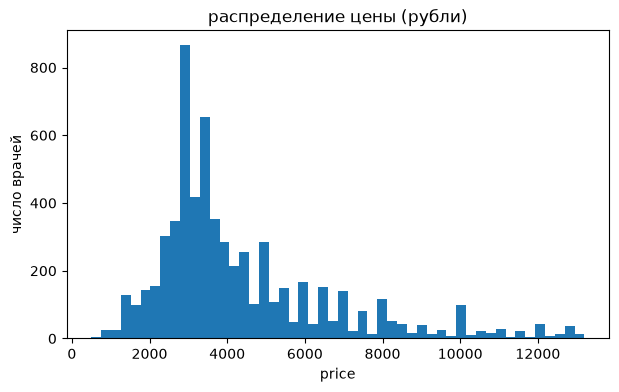

медиана: 3500 
среднее: 4386


In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(data["price"], bins=50)
plt.title("распределение цены (рубли)")
plt.xlabel("price")
plt.ylabel("число врачей")
plt.show()

print("медиана:", round(data["price"].median()),"\nсреднее:", round(data["price"].mean()))

Цены довольно сильно скошены влево, поэтому логарифмируем

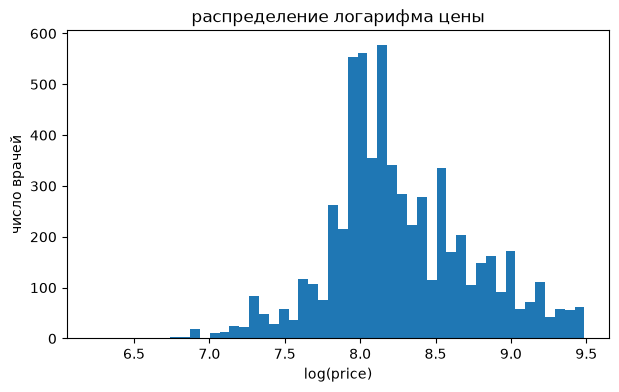

In [164]:
plt.figure(figsize=(7, 4))
plt.hist(np.log1p(data["price"]), bins=50)
plt.title("распределение логарифма цены")
plt.xlabel("log(price)")
plt.ylabel("число врачей")
plt.show()


поэтому

In [165]:
data["price_log"] = np.log1p(data["price"])

Теперь финально разобьем на трейн и тест и сохраним

In [166]:
train_df, test_df = train_test_split(data,test_size=0.2,random_state=69,stratify=data["spec"])
 #stratify следит, чтобы доли специальностей в train и test были такими же, как во всех данных. То есть делит честно, с сохранением пропорций

сохраним

In [167]:
data.to_csv("data_final/dat_for_price_model.csv")
train_df.to_csv("data_final/train.csv")
test_df.to_csv("data_final/test.csv")